# Capstone 2: Business Analysis with Python
## Emporium Sales Territory Analysis
### Author: Luis Alicea

This notebook analyzes in-store data for two EmporiUm sakes territories:
- **Connecticut** (Territory Maneger: Ellen Lemon, Stores 865-872)
- **New York** (Territory Maneger: See Ellefson, Stores 840-851)

The analysis covers monthly revenue, store performance, top customers, product category trends, and a marketing recommendation for next quarter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [3]:
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [4]:
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [5]:
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [6]:
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


## Data Preparation

In [7]:
# Convert Transaction Date to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Add Year and Month columns for grouping later
store_sales['Year'] = store_sales['Transaction Date'].dt.year
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

# Strip any hidden whitespace from Territory Manager column
store_detail['Territory Manager'] = store_detail['Territory Manager'].str.strip()
store_detail['State'] = store_detail['State'].str.strip()

# Get store IDs for two territories
ct_stores = store_detail[store_detail['State'] == 'Connecticut']['Store ID'].tolist()
ny_stores = store_detail[store_detail['State'] == 'New York']['Store ID'].tolist()

print(f"Connecticut stores: {ct_stores}")
print(f"New York stores: {ny_stores}")

# Filter sales to only our two territories
ct_sales = store_sales[store_sales['Store ID'].isin(ct_stores)]
ny_sales = store_sales[store_sales['Store ID'].isin(ny_stores)]

print(f"\nConnecticut transactions: {len(ct_sales)}")
print(f"New York transactions: {len(ny_sales)}")

Connecticut stores: [865, 866, 867, 868, 869, 870, 871, 872]
New York stores: [840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851]

Connecticut transactions: 17378
New York transactions: 31039


# Core Marketing Analysis

## Question 1: Territory Managers and Store Information
- Who are the territory managers for each assigned sales territory?
- What are the store IDs and cities for the stores in each territory?

In [8]:
# Connecticut territory info
ct_info = store_detail[store_detail['State'] == 'Connecticut'][
    ['Store Location', 'Store ID', 'Territory Manager', 'State']
    ].reset_index(drop=True)

# New York territory info
ny_info = store_detail[store_detail['State'] == 'New York'][
    ['Store Location', 'Store ID', 'Territory Manager', 'State']
    ].reset_index(drop=True)

print("=== Connecticut Territory ===")
print(f"Territory Manager: {ct_info['Territory Manager'].iloc[0]}")
print(ct_info[['Store ID', 'Store Location']])

print("\n=== New York Territory ===")
print(f"Territory Manager: {ny_info['Territory Manager'].iloc[0]}")
print(ny_info[['Store ID', 'Store Location']])

=== Connecticut Territory ===
Territory Manager: Ellen Lemon
   Store ID     Store Location
0       865         Bridgeport
1       866             Darien
2       867           Hartford
3       868  Litchfield County
4       869          New Haven
5       870         New London
6       871       Old Saybrook
7       872          Waterbury

=== New York Territory ===
Territory Manager: See Ellefson
    Store ID Store Location
0        840         Albany
1        841        Buffalo
2        842         Elmira
3        843         Ithaca
4        844         Oswego
5        845    Plattsburgh
6        846    Poestenkill
7        847      Rochester
8        848       Syracuse
9        849       Brooklyn
10       850       New York
11       851         Queens


### Findings
- Connecticut territroy is managed by **Ellen Lemon** with 8 stores across cities including Bridgeport, Hartford, New Haven, and Waterbury.
- New York territory is managed by **See Ellefson** with 12 stores across cities including Albany, Buffalo, Brooklyn, New York City, and Rochester.

## Question 2: Monthly Total Revenue by Territory
What is the monthly total revenue for in-store sales in each territory over the full period covered by the data?

In [9]:
# Monthly revenue for Connecticut
ct_monthly = ct_sales.groupby('Month')['Sale Amount'].sum().reset_index()
ct_monthly.columns = ['Month', 'CT Revenue']

# Monthly revenue for New York
ny_monthly = ny_sales.groupby('Month')['Sale Amount'].sum().reset_index()
ny_monthly.columns = ['Month', 'NY Revenue']

# Merge both into one table
monthly_revenue = pd.merge(ct_monthly, ny_monthly, on='Month', how='outer')
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

# Format as currency
monthly_revenue['CT Revenue'] = monthly_revenue['CT Revenue'].round(2)
monthly_revenue['NY Revenue'] = monthly_revenue['NY Revenue'].round(2)

print(monthly_revenue.to_string(index=False))
print(f"\nOverall CT Total: ${ct_monthly['CT Revenue'].sum():,.2f}")
print(f"Overall NY Total: ${ny_monthly['NY Revenue'].sum():,.2f}")
                            

  Month  CT Revenue  NY Revenue
2022-01    29958.25    58635.53
2022-02    25563.98    60262.97
2022-03    33995.57    57143.40
2022-04    31587.12    56880.02
2022-05    37953.48    51805.22
2022-06    32008.85    60549.86
2022-07    30656.27    56250.74
2022-08    42881.99    55052.53
2022-09    30369.64    60495.63
2022-10    43646.37    56896.98
2022-11    25950.41    58402.69
2022-12    34680.64    55006.46
2023-01    38351.45    85210.01
2023-02    53435.37    86906.65
2023-03    50828.54    79964.16
2023-04    45747.20    97173.99
2023-05    39215.78   101370.73
2023-06    39754.07    83465.90
2023-07    49592.69    90818.80
2023-08    48445.34    89422.22
2023-09    49175.79    89196.88
2023-10    45347.65    85095.72
2023-11    42683.73    79627.33
2023-12    50446.82    75904.66
2024-01    57974.76    94306.43
2024-02    49206.33    75083.70
2024-03    46044.68    99439.50
2024-04    38918.30    99105.22
2024-05    41203.81    87328.99
2024-06    48142.95    86955.71
2024-07 

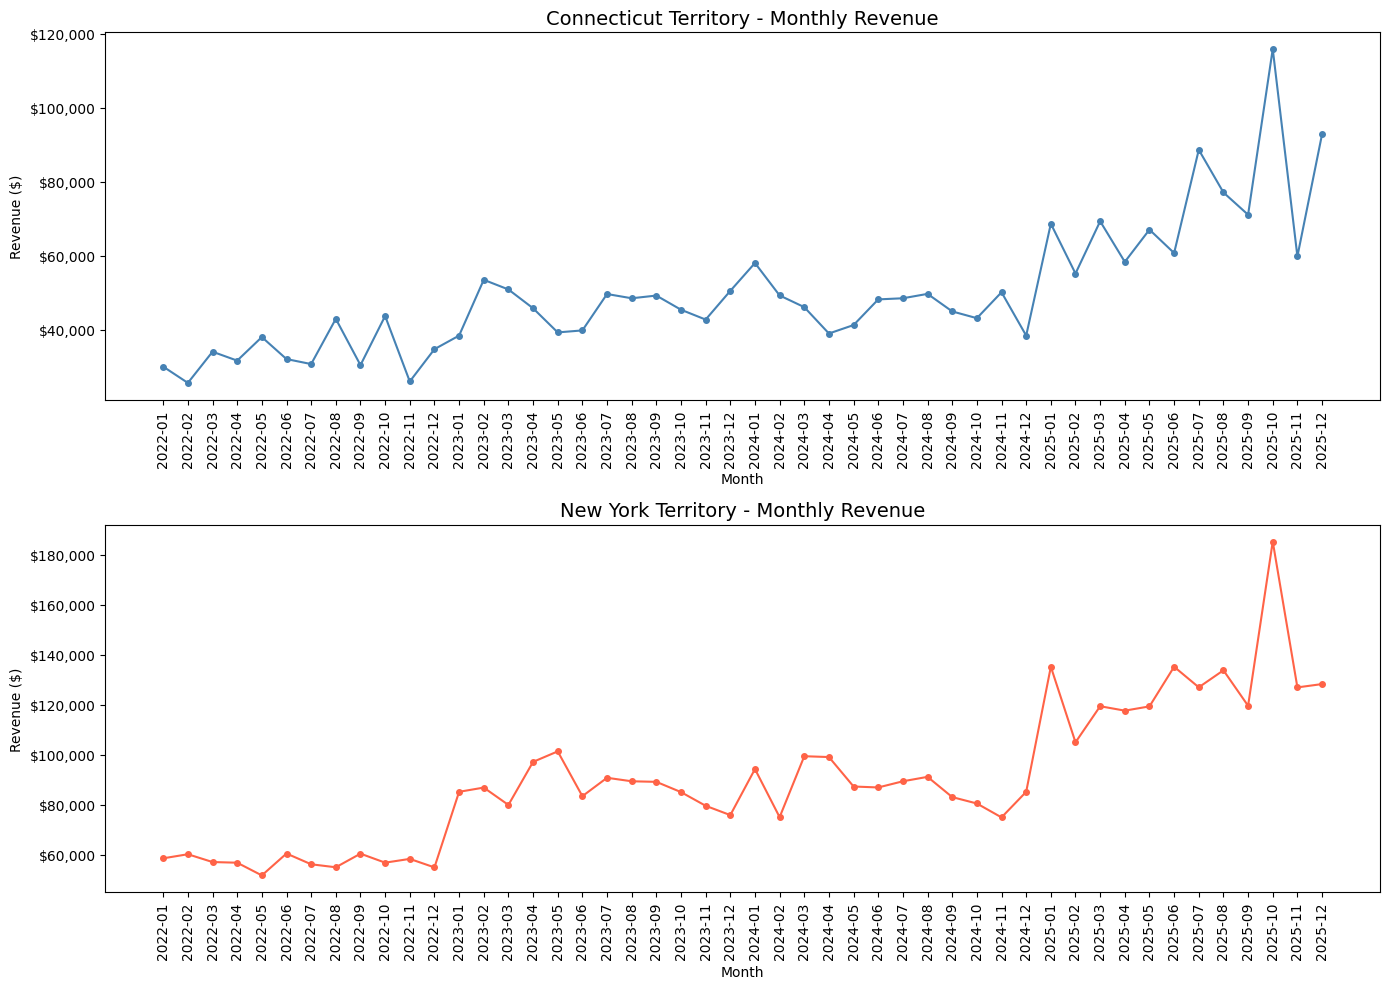

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Connecticut chart
ax1.plot(monthly_revenue['Month'], monthly_revenue['CT Revenue'],
         color='steelblue', marker='o', markersize=4)
ax1.set_title('Connecticut Territory - Monthly Revenue', fontsize=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)')
ax1.tick_params(axis='x', rotation=90)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# New York chart
ax2.plot(monthly_revenue['Month'], monthly_revenue['NY Revenue'],
         color='tomato', marker='o', markersize=4)
ax2.set_title('New York Territory - Monthly Revenue', fontsize=14)
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='x', rotation=90)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Findings
- Both territories show a clear **upward revenue trend** from 2022 through 2025.
- **Connecticut** grew from roughly 30,000 per month in early 2022 to over 110,000 in October 2025 - more than tripling over the data period.
- **New York** grew from roughly 60,000 per month in early 2022 to over 180,000 in October 2025 - also rough tripling.
- Both territories show a consistent **dip in November-December** each year, which is suprising for a retail business - this may suggest the stores are not capturing holiday shopping traffic and could be an opportunity.
- Both territories show a **late spring/early summer dip** (around May-July), possibly reflecting slower student spending outside of back-to-school season.
- **October appears to be the peak month** in both territories, likely driven by back-to-school and semester startup spending.
- New York consistently generates roughly **double the revenue** of Connecticut, which makes sense given it has 12 stores compared to Connecticut's 8.

## Question 3: Store Sales Performance Rankings
- How would you rank the sales performance of each store in each territory?
- Which are the top performing stores?

In [11]:
# Total revenue perstore for Connecticut
ct_store_revenue = ct_sales.groupby('Store ID')['Sale Amount'].agg(
    Total_Revenue='sum',
    Total_Transactions='count',
    Avg_Transaction='mean'
).round(2).reset_index()

# Merge with store names
ct_store_revenue = pd.merge(ct_store_revenue,
    store_detail[['Store ID', 'Store Location']], on='Store ID')

# Rank by total revenue
ct_store_revenue = ct_store_revenue.sort_values(
    'Total_Revenue', ascending=False).reset_index(drop=True)
ct_store_revenue.index += 1
ct_store_revenue['Total_Revenue']= ct_store_revenue['Total_Revenue'].map('${:,.2f}'.format)
ct_store_revenue['Avg_Transaction'] = ct_store_revenue['Avg_Transaction'].map('${:,.2f}'.format)

print("=== Connecticut Store Rankings ===")
print(ct_store_revenue[['Store Location', 'Store ID',
    'Total_Revenue', 'Total_Transactions', 'Avg_Transaction']].to_string())

print()

# Total revenue per store for New York
ny_store_revenue = ny_sales.groupby('Store ID')['Sale Amount'].agg(
    Total_Revenue='sum',
    Total_Transactions='count',
    Avg_Transaction='mean'
).round(2).reset_index()

# Merge with store names
ny_store_revenue = pd.merge(ny_store_revenue,
    store_detail[['Store ID', 'Store Location']], on='Store ID')

# Rank by total revenue
ny_store_revenue = ny_store_revenue.sort_values(
    'Total_Revenue', ascending=False).reset_index(drop=True)
ny_store_revenue.index += 1
ny_store_revenue['Total_Revenue'] = ny_store_revenue['Total_Revenue'].map('${:,.2f}'.format)
ny_store_revenue['Avg_Transaction'] = ny_store_revenue['Avg_Transaction'].map('${:,.2f}'.format)

print("=== New York Store Rankings ===")
print(ny_store_revenue[['Store Location', 'Store ID',
    'Total_Revenue', 'Total_Transactions', 'Avg_Transaction']].to_string())

=== Connecticut Store Rankings ===
      Store Location  Store ID Total_Revenue  Total_Transactions Avg_Transaction
1         New London       870   $331,116.76                2272         $145.74
2         Bridgeport       865   $322,100.07                2231         $144.37
3           Hartford       867   $309,592.06                2133         $145.14
4          Waterbury       872   $295,651.17                2099         $140.85
5          New Haven       869   $286,779.43                2173         $131.97
6  Litchfield County       868   $286,217.15                2127         $134.56
7             Darien       866   $283,455.62                2152         $131.72
8       Old Saybrook       871   $277,310.18                2191         $126.57

=== New York Store Rankings ===
   Store Location  Store ID Total_Revenue  Total_Transactions Avg_Transaction
1        New York       850   $621,565.02                4476         $138.87
2       Rochester       847   $607,148.21      

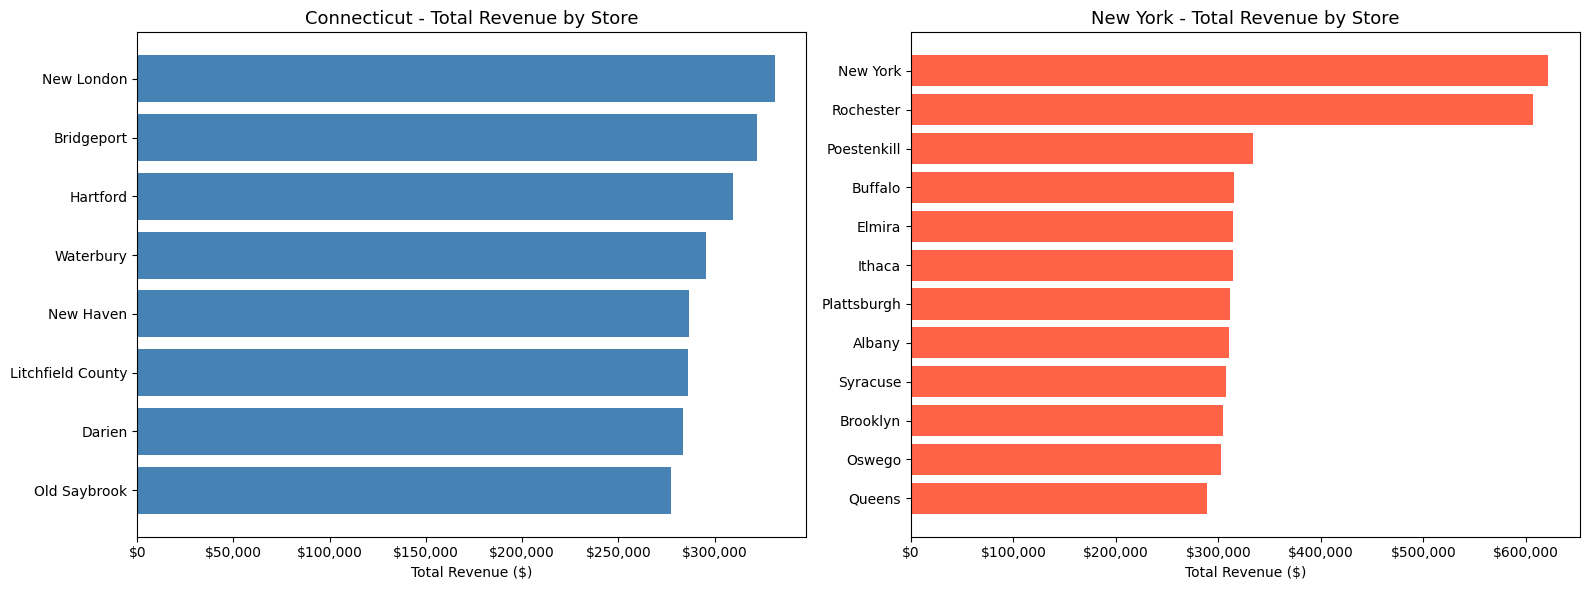

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Connecticut bar chart
ct_plot = ct_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ct_plot = pd.merge(ct_plot, store_detail[['Store ID', 'Store Location']], on='Store ID')
ct_plot = ct_plot.sort_values('Sale Amount', ascending=True)

ax1.barh(ct_plot['Store Location'], ct_plot['Sale Amount'], color='steelblue')
ax1.set_title('Connecticut - Total Revenue by Store', fontsize=13)
ax1.set_xlabel('Total Revenue ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# New York bar chart
ny_plot = ny_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ny_plot = pd.merge(ny_plot, store_detail[['Store ID', 'Store Location']], on='Store ID')
ny_plot = ny_plot.sort_values('Sale Amount', ascending=True)

ax2.barh(ny_plot['Store Location'], ny_plot['Sale Amount'], color='tomato')
ax2.set_title('New York - Total Revenue by Store', fontsize=13)
ax2.set_xlabel('Total Revenue ($)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Findings
**Connecticut Territory:**
- **Top performers:** New London and Bridgeport lead the territory with 
  roughly 330,000 in total revenue each over the data period.
- **Bottom performers:** Old Saybrook and Darien generate the least revenue 
  at roughly 275,000 each — about 15% less than the top stores.
- Connecticut stores are relatively **closely ranked** — the gap between 
  top and bottom is not dramatic, suggesting consistent performance across the territory.

**New York Territory:**
- **Top performers:** New York City and Rochester are clear standouts, 
  each generating over 600,000 in total revenue — nearly double the bottom stores.
- **Bottom performers:** Queens and Oswego generate roughly 300,000 each 
  — significantly behind the top two stores.
- New York shows a much **wider performance gap** than Connecticut, with 
  New York City and Rochester clearly pulling ahead of the rest of the territory.
- The middle tier of stores (Poestenkill, Buffalo, Elmira, Ithaca, Plattsburgh, 
  Albany, Syracuse, Brooklyn) are closely grouped around 300,000-350,000.

## Question 4: Top Customers by Territory
Comparing the customer ID from the customer list with the RewardsID from the sales data, who were the top customers in each territory?

In [13]:
# Merge sales with customer list on RewardsID = cust_id
ct_customers = pd.merge(
    ct_sales[ct_sales['RewardsID'].notna()],
    customer_list[['cust_id', 'name', 'email']],
    left_on='RewardsID',
    right_on='cust_id',
    how='inner'
)

ny_customers = pd.merge(
    ny_sales[ny_sales['RewardsID'].notna()],
    customer_list[['cust_id', 'name', 'email']],
    left_on='RewardsID',
    right_on='cust_id',
    how='inner'
)

# Top 10 customers in Connecticut
ct_top = ct_customers.groupby(['cust_id', 'name', 'email',])['Sale Amount'].agg(
    Total_Spend='sum',
    Total_Transactions='count'
).round(2).reset_index()
ct_top = ct_top.sort_values('Total_Spend', ascending=False).head(10).reset_index(drop=True)
ct_top.index += 1

# Top 10 customers in New York
ny_top = ny_customers.groupby(['cust_id', 'name', 'email',])['Sale Amount'].agg(
    Total_Spend='sum',
    Total_Transactions='count'
).round(2).reset_index()
ny_top = ny_top.sort_values('Total_Spend', ascending=False).head(10).reset_index(drop=True)
ny_top.index += 1

print("=== Top 10 Customers - Connecticut ===")
print(ct_top[['name', 'email', 'Total_Spend', 'Total_Transactions']].to_string())

print("=== Top 10 Customers - New York ===")
print(ny_top[['name', 'email', 'Total_Spend', 'Total_Transactions']].to_string())


=== Top 10 Customers - Connecticut ===
               name                          email  Total_Spend  Total_Transactions
1          Marie S.    marie@lospolloshermanos.biz      4388.87                   8
2          Jon Snow  knowsnothing@westeros.kingdom      3676.21                   6
3        Fox Mulder                 mulder@fbi.gov      3569.60                   6
4        Pugsley A.      pugsley@nevermore.academy      3009.29                   5
5          Helen M.            helen@lawndale.high      2886.72                   6
6            Buford        buford@danvillekids.com      2766.60                   8
7          Jin Kwon          jin@dharma.initiative      2691.89                   8
8   Jean-Luc Picard    picard@enterprise.starfleet      2624.61                   6
9        Miss Piggy    misspiggy@muppetstudios.com      2496.08                  11
10   Cedric Daniels      daniels@westbaltimore.net      2376.77                   5
=== Top 10 Customers - New York ===
 

### Findings

**Connecticut Territory:**
- The top 10 rewards customers are a **tight group** with total spend ranging from 2,376 to 4,388.
- **Marie S.** is the top customer with 4,388 in total spend across 8 transactions.
- **Miss Piggy** is notable for living the most transactions (11) despite ranking 9th in total spend.

**New York Territory:**
- **Julian Bashir** is a clear outlier at the top with 6,039 in total spend across 10 transactions.
- The remaining top 10 are closely grouped between 3,159 and 3,918.
- **Peggy Olson** and **Gonzo** both have 11 transactions.

**Oppoertunity:**
- Julian Bashir in New York could be a candidate for a VIP rewards tier given his significantly higher spend compared to other customers.
- Miss Piggy and Peggy Olson's high transaction frequency suggests these customers respond well to repeat visit incentives.

## Question 5: transactions and Revenue by Product Cetegory
- What is the number of transactions per month by product catecory in each territory?
- What is total sales revenue per month by category? What might this tell us about the most popular products and where there could be opportunity for growth?

In [14]:
# Merge products with categories to get category names
products_full = pd.merge(products, product_categories[['CategoryID', 'Category']],
                         on='CategoryID', how='left')

# Merge CT sales with products
ct_cat = pd.merge(ct_sales, products_full[['Prod Num', 'Category']],
                  on='Prod Num', how='left')

# Merge NY sales with products
ny_cat = pd.merge(ny_sales, products_full[['Prod Num', 'Category']],
                  on='Prod Num', how='left')

# Check for any unmatched products
print(f"CT unmatched products: {ct_cat['Category'].isna().sum()}")
print(f"NY unmatched products: {ny_cat['Category'].isna().sum()}")

CT unmatched products: 0
NY unmatched products: 0


In [15]:
# Connecticut - transactions and revenue by category
ct_cat_summary = ct_cat.groupby('Category')['Sale Amount'].agg(
    Total_Transactions='count',
    Total_Revenue='sum'
).round(2).reset_index()
ct_cat_summary = ct_cat_summary.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
ct_cat_summary.index += 1

#New York - transactions and revenue by category
ny_cat_summary = ny_cat.groupby('Category')['Sale Amount'].agg(
    Total_Transactions='count',
    Total_Revenue='sum'
).round(2).reset_index()
ny_cat_summary = ny_cat_summary.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
ny_cat_summary.index += 1

print("=== Connecticut - Revenue and Transactions by Category ===")
print(ct_cat_summary.to_string())
print("\n=== New York - Revenue and Transactions by Category ===")
print(ny_cat_summary.to_string())

=== Connecticut - Revenue and Transactions by Category ===
                   Category  Total_Transactions  Total_Revenue
1  Technology & Accessories               25655    11955289.08
2                 Textbooks               25971     4493254.81
3              Art Supplies               31240     1001627.44
4   Apparel and Merchandise               27168      857295.12
5   Stationery and Supplies               40909      407380.16
6           Books (General)                5588      162371.20

=== New York - Revenue and Transactions by Category ===
                   Category  Total_Transactions  Total_Revenue
1  Technology & Accessories               45164    21498107.75
2                 Textbooks               48664     8435652.94
3              Art Supplies               55572     1747094.69
4   Apparel and Merchandise               49032     1585641.12
5   Stationery and Supplies               72039      724130.99
6           Books (General)                9732      279677.12


In [16]:
# Connecticut monthly transactions by category
ct_monthly_cat = ct_cat.groupby(['Month', 'Category'])['Sale Amount'].agg(
    Transactions='count',
    Revenue='sum'
).round(2).reset_index()
ct_monthly_cat['Month'] = ct_monthly_cat['Month'].astype(str)

# New York monthly transactions by category
ny_monthly_cat = ny_cat.groupby(['Month', 'Category'])['Sale Amount'].agg(
    Transactions='count',
    Revenue='sum'
).round(2).reset_index()
ny_monthly_cat['Month'] = ny_monthly_cat['Month'].astype(str)

print("Connecticut monthly category sample (first 10 rows):")
print(ct_monthly_cat.head(10).to_string())

Connecticut monthly category sample (first 10 rows):
     Month                  Category  Transactions    Revenue
0  2022-01   Apparel and Merchandise           336    9786.00
1  2022-01              Art Supplies           319    7184.32
2  2022-01           Books (General)            76    1958.40
3  2022-01   Stationery and Supplies           396    3679.39
4  2022-01  Technology & Accessories           315  153020.42
5  2022-01                 Textbooks           341   59375.03
6  2022-02   Apparel and Merchandise           352   12032.80
7  2022-02              Art Supplies           264    8048.15
8  2022-02           Books (General)            68    1756.40
9  2022-02   Stationery and Supplies           396    3699.63


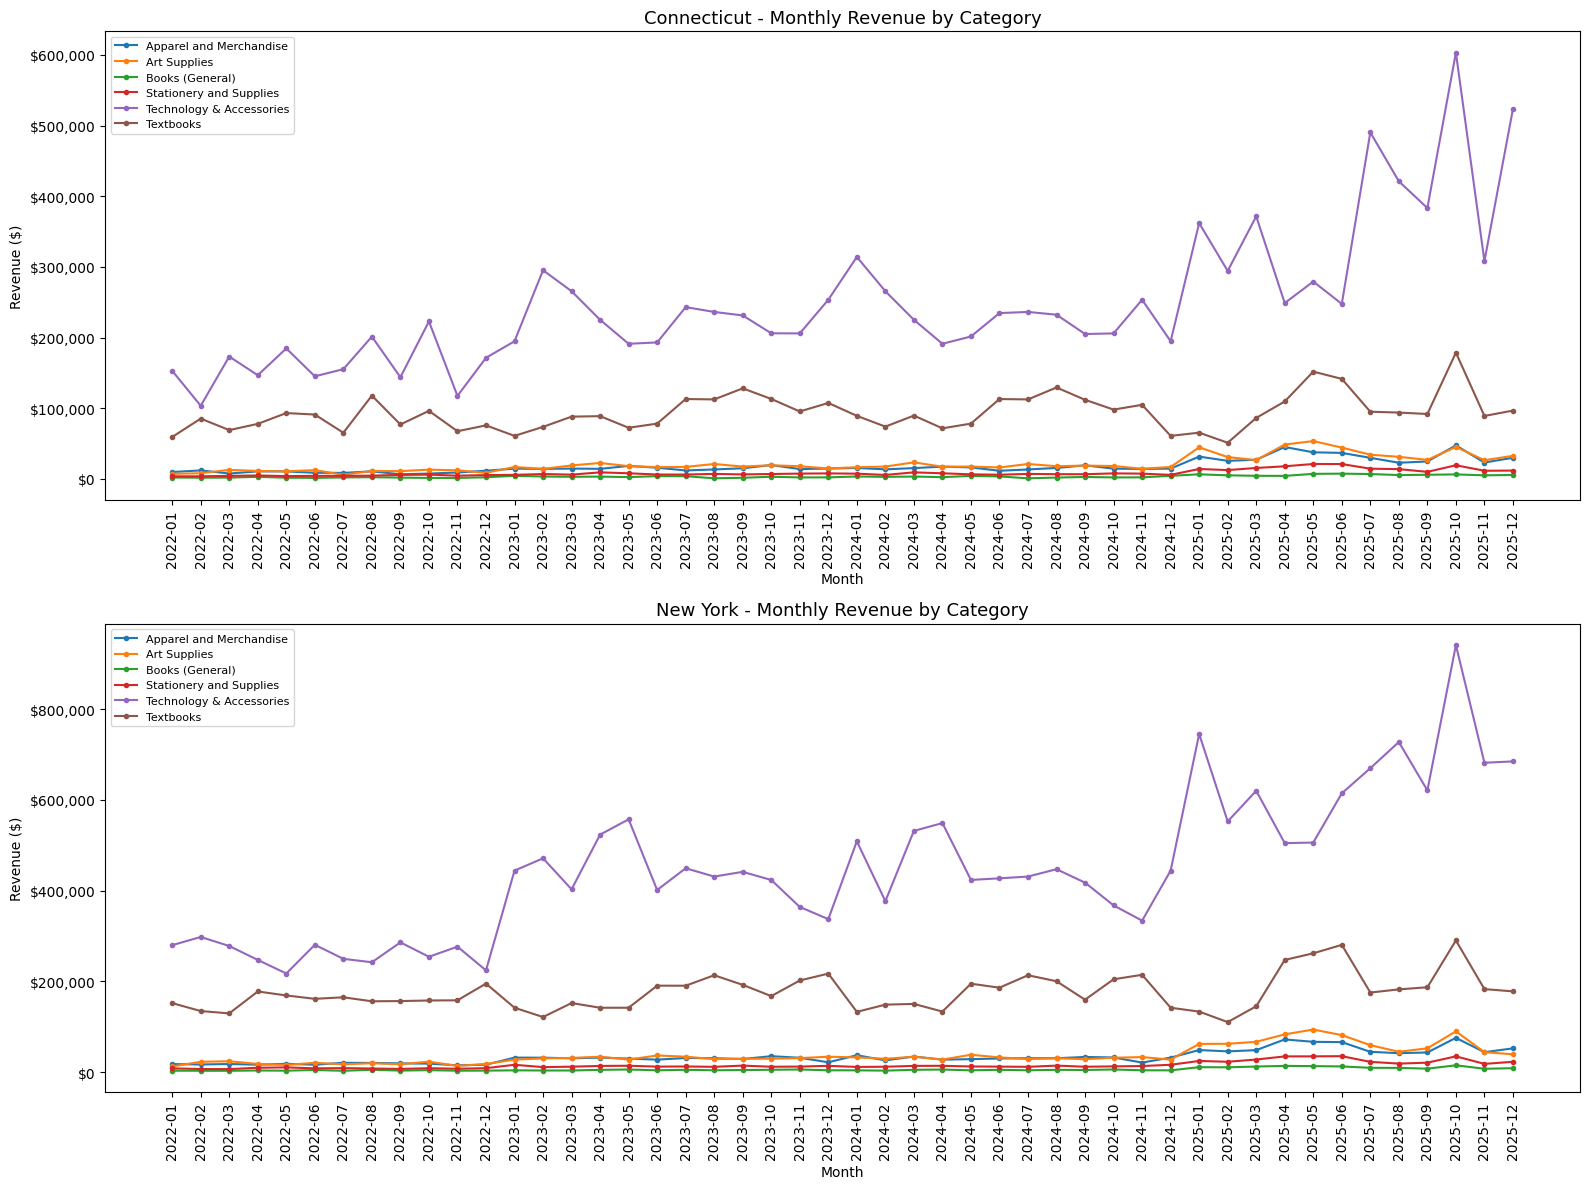

In [17]:
# Chart - Monthly revenue by category for both territories
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Connecticut - monthly revenue by category
for category in ct_monthly_cat['Category'].unique():
    data = ct_monthly_cat[ct_monthly_cat['Category'] == category]
    ax1.plot(data['Month'], data['Revenue'], marker='o', 
             markersize=3, label=category)

ax1.set_title('Connecticut - Monthly Revenue by Category', fontsize=13)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)')
ax1.tick_params(axis='x', rotation=90)
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# New York - monthly revenue by category
for category in ny_monthly_cat['Category'].unique():
    data = ny_monthly_cat[ny_monthly_cat['Category'] == category]
    ax2.plot(data['Month'], data['Revenue'], marker='o',
             markersize=3, label=category)

ax2.set_title('New York - Monthly Revenue by Category', fontsize=13)
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='x', rotation=90)
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

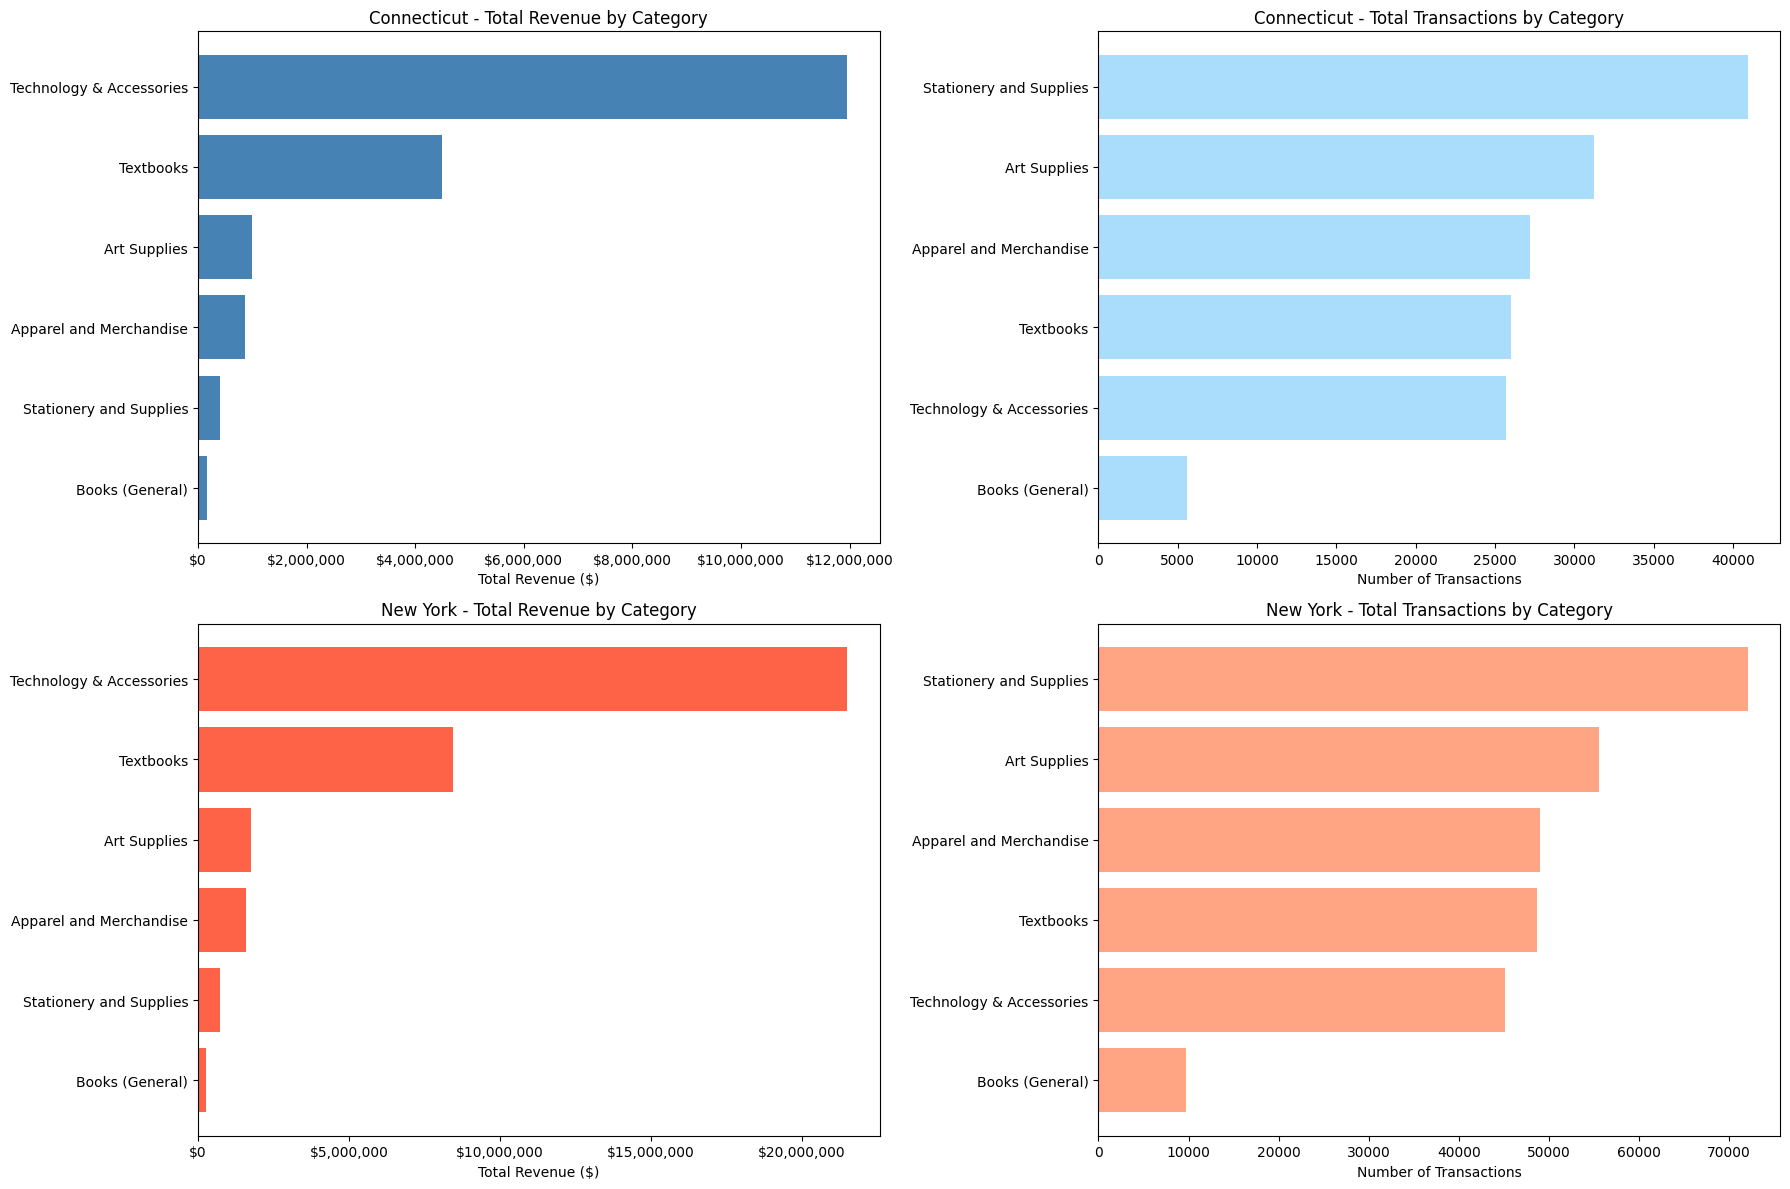

In [18]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Connecticut - Revenue by Category
ct_rev = ct_cat_summary.sort_values('Total_Revenue', ascending=True)
ax1.barh(ct_rev['Category'], ct_rev['Total_Revenue'], color='steelblue')
ax1.set_title('Connecticut - Total Revenue by Category', fontsize=12)
ax1.set_xlabel('Total Revenue ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Connecticut - Transactions by Category
ct_trans = ct_cat_summary.sort_values('Total_Transactions', ascending=True)
ax2.barh(ct_trans['Category'], ct_trans['Total_Transactions'], color='lightskyblue', alpha=0.7)
ax2.set_title('Connecticut - Total Transactions by Category', fontsize=12)
ax2.set_xlabel('Number of Transactions')

# New York - Revenue by Category
ny_rev = ny_cat_summary.sort_values('Total_Revenue', ascending=True)
ax3.barh(ny_rev['Category'], ny_rev['Total_Revenue'], color='tomato')
ax3.set_title('New York - Total Revenue by Category', fontsize=12)
ax3.set_xlabel('Total Revenue ($)')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# New York - Transactions by Category
ny_trans = ny_cat_summary.sort_values('Total_Transactions', ascending=True)
ax4.barh(ny_trans['Category'], ny_trans['Total_Transactions'], color='coral', alpha=0.7)
ax4.set_title('New York - Total Transactions by Category', fontsize=12)
ax4.set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()

### Findings

**Revenue vs Transactions:**
- **Technology and Accessories** dominates revenue in both territories — 
  11.9 million in Connecticut and 21.5 million in New York — despite not 
  having the most transactions. High price point drives outsized revenue.
- **Textbooks** is a solid second at 4.5 million and 8.4 million respectively, 
  reflecting core student bookstore demand.
- **Stationery and Supplies** has the most transactions in both territories 
  but generates the least revenue — high volume, very low price point.
- **Books (General)** has the fewest transactions and lowest revenue — 
  surprising for a bookstore chain and a clear growth opportunity.

**Monthly Trends:**
- Technology and Accessories towers above all other categories every month 
  in both territories, with revenue nearly tripling from 2022 to 2025.
- Both territories show a consistent **October spike** across categories 
  driven by back-to-school spending.
- All other categories remain relatively flat over the full data period.

**Growth Opportunities:**
- **Books (General)** is underperforming and could benefit from targeted 
  promotions such as book clubs or author events.
- **Stationery and Supplies** drives high foot traffic — bundling with 
  higher margin products could increase revenue per visit.
- Over-reliance on Technology revenue suggests diversifying into other 
  categories should be a medium-term goal.

## Question 6: Marketing Recommendation for Next Quarter
Based on the full analysis, where should marketing attention be focused in the next quarter?

In [19]:
# Calculate revenue per transaction by category to support recommendation
ct_cat_summary['Rev_Per_Transaction'] = (
    ct_cat_summary['Total_Revenue'] / ct_cat_summary['Total_Transactions']
).round(2)

ny_cat_summary['Rev_Per_Transaction'] = (
    ny_cat_summary['Total_Revenue'] / ny_cat_summary['Total_Transactions']
).round(2)

print("=== Connecticut - Revenue Per Transaction by Category ===")
print(ct_cat_summary[['Category', 'Rev_Per_Transaction']].sort_values(
    'Rev_Per_Transaction', ascending=False).to_string())

print("=== New York - Revenue Per Transaction by Category ===")
print(ny_cat_summary[['Category', 'Rev_Per_Transaction']].sort_values(
    'Rev_Per_Transaction', ascending=False).to_string())

=== Connecticut - Revenue Per Transaction by Category ===
                   Category  Rev_Per_Transaction
1  Technology & Accessories               466.00
2                 Textbooks               173.01
3              Art Supplies                32.06
4   Apparel and Merchandise                31.56
6           Books (General)                29.06
5   Stationery and Supplies                 9.96
=== New York - Revenue Per Transaction by Category ===
                   Category  Rev_Per_Transaction
1  Technology & Accessories               476.00
2                 Textbooks               173.34
4   Apparel and Merchandise                32.34
3              Art Supplies                31.44
6           Books (General)                28.74
5   Stationery and Supplies                10.05


### Marketing Recommendation for Next Quarter

Based on the full analysis, three priority actions are recommended for next quarter:

**Priority 1: Capture the October Peak Early**
Both territories consistently peak in October driven by back-to-school spending. 
This is the single biggest revenue opportunity of the year. Marketing campaigns 
combining Technology bundles and Textbook promotions should launch in mid-September 
to maximize this window. Given that Technology generates 466-476 per transaction, 
even a modest increase in October tech sales would have significant revenue impact.

**Priority 2: Address the Holiday Revenue Dip**
Both territories show a surprising drop in November-December — an unusual pattern 
for a retail chain. Holiday gift promotions, tech gift bundles, and gift card 
campaigns should be tested this quarter to capture holiday traffic currently 
going to competitors. If successful, this could add a second annual revenue peak.

**Priority 3: Grow the Books (General) Category**
Books (General) generates only 29 per transaction and has the lowest transaction 
count of any category — a significant underperformance for a bookstore chain. 
Book clubs, author events, and reading promotions are low-cost marketing investments 
that could drive foot traffic and grow this underdeveloped category. Success here 
would also reduce over-reliance on Technology as the dominant revenue driver.

**Note:** Store-level and customer retention strategies are longer-term investments 
that should be revisited in the following quarter once the above priorities are underway.